
# PDEBench-Lang: BART Frozen-Backbone Baseline

**Goal:** Evaluate a stronger baseline where `facebook/bart-base` stays frozen and only the multitask classification heads are trained.

**Evaluation:** Compare the head-only model across four PDE representations:
- natural
- LaTeX
- prefix
- postfix

**Note:** The original Phase 2 fine-tuning cells are kept only for reference. The main baseline in this notebook is now “no backbone fine-tuning,” not “no training at all.”


## Phase 1: Data/Task Setup

In [25]:
# Install required packages in the active kernel environment
import sys
!{sys.executable} -m pip install -q "transformers[torch]" "accelerate>=1.1.0" datasets evaluate rouge_score scikit-learn

In [26]:
import json
import os
import random
import numpy as np
import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    BartTokenizer,
    BartForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)
import evaluate

# Set reproducible config
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Configuration
CONFIG = {
    "model_name": "facebook/bart-base",
    "max_input_length": 128,
    "max_output_length": 256,
    "learning_rate": 3e-4,
    "batch_size": 16,
    "num_epochs": 3,
    "val_split": 0.1,
    "seed": SEED,
}
DIALECTS = ["natural", "latex", "prefix", "postfix"]
MODELS_DIR = "./models"
LOG_DIR = "./logs"
os.environ["TENSORBOARD_LOGGING_DIR"] = LOG_DIR
os.makedirs(LOG_DIR, exist_ok=True)

print(f"Configuration: {CONFIG}")
print(f"Dialects: {DIALECTS}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():  # Mac with Apple Silicon
    device = torch.device("mps")
else:
    device = torch.device("cpu")

use_cuda = device.type == "cuda"
if use_cuda:

    torch.backends.cudnn.benchmark = True

print(f"Using device: {device}")
print(f"CUDA acceleration enabled: {use_cuda}")

Configuration: {'model_name': 'facebook/bart-base', 'max_input_length': 128, 'max_output_length': 256, 'learning_rate': 0.0003, 'batch_size': 16, 'num_epochs': 3, 'val_split': 0.1, 'seed': 42}
Dialects: ['natural', 'latex', 'prefix', 'postfix']
Using device: mps
CUDA acceleration enabled: False


In [27]:
# Load dataset and validate schema
def load_dataset_jsonl(filepath):
    """Load dataset from JSONL file and validate required fields."""
    data = []
    required_fields = ["family", "dialects", "labels"]

    with open(filepath, "r") as f:
        for line_num, line in enumerate(f, 1):
            instance = json.loads(line.strip())

            # Validate schema
            for field in required_fields:
                if field not in instance:
                    raise ValueError(f"Line {line_num}: Missing required field '{field}'")

            # Validate nested fields
            for dialect in DIALECTS:
                if dialect not in instance["dialects"]:
                    raise ValueError(f"Line {line_num}: Missing 'dialects.{dialect}'")
            if "behavioral" not in instance["labels"]:
                raise ValueError(f"Line {line_num}: Missing 'labels.behavioral'")
            if "operators" not in instance["labels"]:
                raise ValueError(f"Line {line_num}: Missing 'labels.operators'")
            if "reasoning" not in instance["labels"]:
                raise ValueError(f"Line {line_num}: Missing 'labels.reasoning'")

            data.append(instance)

    return data

# Load the dataset
dataset_path = "varied_data_generation/dataset.jsonl"
raw_data = load_dataset_jsonl(dataset_path)

print(f"Loaded {len(raw_data)} instances")
print(f"\nSample instance:")
print(json.dumps(raw_data[0], indent=2))

Loaded 10000 instances

Sample instance:
{
  "family": "Advection",
  "coefficients": {
    "c": 1.23
  },
  "dialects": {
    "latex": "\\frac{\\partial}{\\partial t} u{\\left(t,x \\right)} + 1.23 \\frac{\\partial}{\\partial x} u{\\left(t,x \\right)} = 0",
    "prefix": "=(+(*(1.23000000000000, d(u(t, x), x)), d(u(t, x), t)), 0)",
    "postfix": "1.23000000000000 u(t, x) x d * u(t, x) t d + 0 =",
    "natural": "u propagates without diffusion: u_t plus 1.23 times u_x equals zero."
  },
  "labels": {
    "behavioral": "Advection",
    "operators": [
      "exp",
      "polynomial"
    ],
    "reasoning": "No second-order spatial derivative; only u_t and 1.23*u_x appear \u2014 this is advection, not diffusion, at speed 1.23."
  }
}


In [28]:
# Analyze family distribution
from collections import Counter

family_counts = Counter(instance["family"] for instance in raw_data)
print("PDE Family Distribution:")
print("-" * 30)
for family, count in sorted(family_counts.items()):
    print(f"{family}: {count} ({count/len(raw_data)*100:.1f}%)")

PDE Family Distribution:
------------------------------
Advection: 2000 (20.0%)
Burgers: 2000 (20.0%)
Heat: 2000 (20.0%)
Laplace: 2000 (20.0%)
Wave: 2000 (20.0%)


In [29]:
# Define input extractor for BART classification
def extract_text(instance, dialect="natural"):
    """Return a PDE description in the selected dialect."""
    return instance["dialects"][dialect]

# Extract the label (PDE family)
def extract_label(instance):
    """Return the PDE family label."""
    return instance["labels"]["behavioral"]

# Preview example
sample = raw_data[10]

print("Input samples by dialect:")
for dialect in DIALECTS:
    print(f"{dialect}: {extract_text(sample, dialect)}")

print("\nLabel:")
print(extract_label(sample))

Input samples by dialect:
natural: Wave propagation with speed 2.0: the second-order time change equals 2.0^2 times the second-order spatial change.
latex: \frac{\partial^{2}}{\partial t^{2}} u{\left(t,x \right)} = 4.0 \frac{\partial^{2}}{\partial x^{2}} u{\left(t,x \right)}
prefix: =(d(d(u(t, x), t), t), *(4.00000000000000, d(d(u(t, x), x), x)))
postfix: u(t, x) t d t d 4.00000000000000 u(t, x) x d x d * =

Label:
Wave


In [30]:
# Build label mappings
families = sorted(set(extract_label(d) for d in raw_data))

label2id = {f: i for i, f in enumerate(families)}
id2label = {i: f for f, i in label2id.items()}

print("Label mapping:")
print(label2id)

Label mapping:
{'Advection': 0, 'Burgers': 1, 'Heat': 2, 'Laplace': 3, 'Wave': 4}


## Phase 2: Legacy Fine-Tuning Pipeline (Reference Only)


In [31]:
# Build stratified train/validation/test split by family
labels = [instance["family"] for instance in raw_data]

train_val, test_data = train_test_split(
    raw_data,
    test_size=0.1,
    stratify=labels,
    random_state=CONFIG["seed"]
)

train_data, val_data = train_test_split(
    train_val,
    test_size=CONFIG["val_split"] / (1.0 - CONFIG["val_split"]),
    stratify=[d["family"] for d in train_val],
    random_state=CONFIG["seed"],
)

print(f"Train size: {len(train_data)}")
print(f"Validation size: {len(val_data)}")
print(f"Test size: {len(test_data)}")

# Verify balanced distribution
train_families = Counter(d["family"] for d in train_data)
val_families = Counter(d["family"] for d in val_data)
test_families = Counter(d["family"] for d in test_data)

print("\nTrain distribution:")
for family, count in sorted(train_families.items()):
    print(f"  {family}: {count}")

print("\nValidation distribution:")
for family, count in sorted(val_families.items()):
    print(f"  {family}: {count}")

print("\nTest distribution:")
for family, count in sorted(test_families.items()):
    print(f"  {family}: {count}")

Train size: 7999
Validation size: 1001
Test size: 1000

Train distribution:
  Advection: 1600
  Burgers: 1600
  Heat: 1600
  Laplace: 1599
  Wave: 1600

Validation distribution:
  Advection: 200
  Burgers: 200
  Heat: 200
  Laplace: 201
  Wave: 200

Test distribution:
  Advection: 200
  Burgers: 200
  Heat: 200
  Laplace: 200
  Wave: 200


In [32]:
# Initialize tokenizer and model
# Note: `facebook/bart-base` does not include a pretrained classification head,
# so the classification head weights are initialized randomly and must be trained.
tokenizer = BartTokenizer.from_pretrained(CONFIG["model_name"])
model = BartForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)
model.to(device)


print(f"Model loaded: {CONFIG['model_name']}")
print(f"Model parameters: {model.num_parameters():,}")

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded: facebook/bart-base
Model parameters: 140,014,853


In [33]:
# Preprocess and tokenize for BART classification

def preprocess_data(data):
    """Convert raw data into text and label."""

    texts = [d["dialects"]["natural"] for d in data]
    labels = [label2id[d["labels"]["behavioral"]] for d in data]

    return {
        "text": texts,
        "label": labels
    }


def tokenize_function(examples):
    """Tokenize text inputs for BART."""

    tokenized = tokenizer(
        examples["text"],
        max_length=CONFIG["max_input_length"],
        truncation=True,
        padding="max_length"
    )

    tokenized["labels"] = examples["label"]

    return tokenized


# Create datasets
train_processed = preprocess_data(train_data)
val_processed = preprocess_data(val_data)

train_dataset = Dataset.from_dict(train_processed)
val_dataset = Dataset.from_dict(val_processed)


# Tokenize datasets
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "label"]
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text", "label"]
)


print(f"Train dataset: {len(train_tokenized)} examples")
print(f"Validation dataset: {len(val_tokenized)} examples")

Map:   0%|          | 0/7999 [00:00<?, ? examples/s]

Map:   0%|          | 0/1001 [00:00<?, ? examples/s]

Train dataset: 7999 examples
Validation dataset: 1001 examples


In [34]:
# Check input truncation for BART classification
def check_truncation(data, max_input):
    """Check how many examples exceed the input token limit."""

    input_truncated = 0

    for instance in data:
        text = instance["dialects"]["natural"]

        tokens = tokenizer(
            text,
            return_length=True,
            padding=False,
            truncation=False,
        )["length"]

        if isinstance(tokens, list):
            tokens = tokens[0]

        if tokens > max_input:
            input_truncated += 1

    return input_truncated


input_trunc = check_truncation(
    raw_data,
    CONFIG["max_input_length"]
)

print(
    f"Input truncation: {input_trunc}/{len(raw_data)} "
    f"({input_trunc/len(raw_data)*100:.2f}%)"
)

Input truncation: 0/10000 (0.00%)


In [35]:
# Setup training arguments
training_args = TrainingArguments(
    output_dir="./bart_pde_results",
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    learning_rate=CONFIG["learning_rate"],
    eval_strategy="epoch",
    save_strategy="epoch",
    weight_decay=0.01,
    load_best_model_at_end=True,
    fp16=use_cuda,
)


# Data collator
# The Trainer will automatically place tensors on the selected device.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [36]:
# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
)

print("Trainer initialized successfully")

Trainer initialized successfully


In [37]:
# Fine-tuning is intentionally disabled in this notebook.
print("Phase 2 fine-tuning is disabled in BART_PDE_Classification_no_fine_tune.ipynb.")
print("Run the Phase 3 baseline cells to evaluate pretrained BART across natural, LaTeX, prefix, and postfix inputs.")


Phase 2 fine-tuning is disabled in BART_PDE_Classification_no_fine_tune.ipynb.
Run the Phase 3 baseline cells to evaluate pretrained BART across natural, LaTeX, prefix, and postfix inputs.



## Phase 3: Frozen BART Backbone Baseline (Head-Only Training)

This phase keeps the pretrained BART backbone frozen and trains only the multitask heads.

What changes here:
- the pretrained BART backbone is frozen
- the task heads are still trained on the PDE classification / structure objectives
- evaluation still covers natural, LaTeX, prefix, and postfix inputs
- dialect tags stay disabled so the baseline is not affected by frozen random embeddings for newly added special tokens
- CPU is requested in the command below for stability if Apple MPS stalls
- family classification plus operator prediction
- auxiliary structural targets: time order, spatial derivatives, nonlinearity, and spatial variable count

This is a much more meaningful baseline than the earlier evaluation-only sanity check because the classifier heads can still learn the task while the language backbone stays fixed.


In [38]:

from pathlib import Path
import json
import subprocess
import sys
import matplotlib.pyplot as plt

PDE_DIALECTS = ['natural', 'latex', 'prefix', 'postfix']
FROZEN_DEVICE = 'cpu'
FROZEN_OUTPUT_ROOT = Path('outputs') / 'bart_multitask_pde_frozen_backbone'
FROZEN_ROOT_DIR = FROZEN_OUTPUT_ROOT / 'instance'
FROZEN_OUTPUT_DIR = FROZEN_ROOT_DIR / 'mixed_frozen_backbone'
FROZEN_METRICS_PATH = FROZEN_OUTPUT_DIR / 'multitask_metrics.json'
HELD_OUT_DATASETS = sorted(Path('varied_data_generation').glob('held_out*.jsonl'))
HELD_OUT_DATASET_INFO = {
    'held_out_kleingordon': {
        'display_name': 'KleinGordon',
        'closest_seen_family': 'Wave',
        'structural_note': 'same second-order time/space pattern as Wave, plus an added mass term',
    },
    'held_out_reactiondiffusion': {
        'display_name': 'ReactionDiffusion',
        'closest_seen_family': 'Heat / Burgers',
        'structural_note': 'heat-like diffusion term plus a Burgers-like nonlinear reaction term',
    },
    'held_out_beam': {
        'display_name': 'Beam',
        'closest_seen_family': 'Wave',
        'structural_note': 'same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative',
    },
    'held_out_dataset': {
        'display_name': 'Legacy held_out_dataset',
        'closest_seen_family': 'Wave',
        'structural_note': 'legacy held-out file; currently KleinGordon-style in this repo snapshot',
    },
}

print(f'Working directory: {Path.cwd()}')
print(f'Expected metrics path: {FROZEN_METRICS_PATH}')
print(f'Frozen-backbone device: {FROZEN_DEVICE}')
if HELD_OUT_DATASETS:
    print('Held-out datasets:')
    for dataset_path in HELD_OUT_DATASETS:
        print(f'  - {dataset_path}')
else:
    print('No held-out datasets found under varied_data_generation/.')


Working directory: /Users/chenyixin/Documents/CSCI5541/group project/Nlp-group-final-project
Expected metrics path: outputs/bart_multitask_pde_frozen_backbone/instance/mixed_frozen_backbone/multitask_metrics.json
Frozen-backbone device: cpu
Held-out datasets:
  - varied_data_generation/held_out_beam.jsonl
  - varied_data_generation/held_out_dataset.jsonl
  - varied_data_generation/held_out_kleingordon.jsonl
  - varied_data_generation/held_out_reactiondiffusion.jsonl


In [39]:

REPORT_CMD = [
    sys.executable,
    'scripts/run_bart_multitask_pde.py',
    '--report-only',
    '--train-mode', 'mixed',
    '--split-mode', 'instance',
    '--output-root', str(FROZEN_OUTPUT_ROOT),
    '--freeze-backbone',
    '--no-dialect-token',
    '--device', FROZEN_DEVICE,
]

if HELD_OUT_DATASETS:
    REPORT_CMD.extend(['--held-out-datasets', *[str(path) for path in HELD_OUT_DATASETS]])

print(' '.join(REPORT_CMD))
subprocess.run(REPORT_CMD, check=True)


/usr/local/bin/python3 scripts/run_bart_multitask_pde.py --report-only --train-mode mixed --split-mode instance --output-root outputs/bart_multitask_pde_frozen_backbone --freeze-backbone --no-dialect-token --device cpu --held-out-datasets varied_data_generation/held_out_beam.jsonl varied_data_generation/held_out_dataset.jsonl varied_data_generation/held_out_kleingordon.jsonl varied_data_generation/held_out_reactiondiffusion.jsonl
Split sizes:
  train=8000  val=1000  test=1000
Family counts:
  train={'Advection': 1600, 'Burgers': 1600, 'Heat': 1600, 'Laplace': 1600, 'Wave': 1600}
  val={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
  test={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
Train/Test overlap diagnostics:
  natural exact-overlap=752/1000 (75.2%), unique-overlap=519
  latex   exact-overlap=997/1000 (99.7%), unique-overlap=539
  prefix  exact-overlap=997/1000 (99.7%), unique-overlap=539
  postfix exact-overlap=997/1000

CompletedProcess(args=['/usr/local/bin/python3', 'scripts/run_bart_multitask_pde.py', '--report-only', '--train-mode', 'mixed', '--split-mode', 'instance', '--output-root', 'outputs/bart_multitask_pde_frozen_backbone', '--freeze-backbone', '--no-dialect-token', '--device', 'cpu', '--held-out-datasets', 'varied_data_generation/held_out_beam.jsonl', 'varied_data_generation/held_out_dataset.jsonl', 'varied_data_generation/held_out_kleingordon.jsonl', 'varied_data_generation/held_out_reactiondiffusion.jsonl'], returncode=0)

In [ ]:

BASELINE_CMD = [
    sys.executable,
    'scripts/run_bart_multitask_pde.py',
    '--train-mode', 'mixed',
    '--split-mode', 'instance',
    '--output-root', str(FROZEN_OUTPUT_ROOT),
    '--freeze-backbone',
    '--no-dialect-token',
    '--device', FROZEN_DEVICE,
]

if HELD_OUT_DATASETS:
    BASELINE_CMD.extend(['--held-out-datasets', *[str(path) for path in HELD_OUT_DATASETS]])

print(' '.join(BASELINE_CMD))
subprocess.run(BASELINE_CMD, check=True)


/usr/local/bin/python3 scripts/run_bart_multitask_pde.py --train-mode mixed --split-mode instance --output-root outputs/bart_multitask_pde_frozen_backbone --freeze-backbone --no-dialect-token --device cpu --held-out-datasets varied_data_generation/held_out_beam.jsonl varied_data_generation/held_out_dataset.jsonl varied_data_generation/held_out_kleingordon.jsonl varied_data_generation/held_out_reactiondiffusion.jsonl
Split sizes:
  train=8000  val=1000  test=1000
Family counts:
  train={'Advection': 1600, 'Burgers': 1600, 'Heat': 1600, 'Laplace': 1600, 'Wave': 1600}
  val={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
  test={'Advection': 200, 'Burgers': 200, 'Heat': 200, 'Laplace': 200, 'Wave': 200}
Train/Test overlap diagnostics:
  natural exact-overlap=752/1000 (75.2%), unique-overlap=519
  latex   exact-overlap=997/1000 (99.7%), unique-overlap=539
  prefix  exact-overlap=997/1000 (99.7%), unique-overlap=539
  postfix exact-overlap=997/1000 (99.7%), uniq

Some weights of BartPDEMultitaskClassifier were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['family_head.bias', 'family_head.weight', 'first_spatial_head.bias', 'first_spatial_head.weight', 'nonlinear_head.bias', 'nonlinear_head.weight', 'operator_head.bias', 'operator_head.weight', 'second_spatial_head.bias', 'second_spatial_head.weight', 'spatial_var_head.bias', 'spatial_var_head.weight', 'time_order_head.bias', 'time_order_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Freezing the pretrained BART backbone and training only the multitask heads.
Parameter counts: trainable=13,842 / total=139,434,258 (0.01% trainable)


  0%|          | 25/8000 [06:09<29:20:51, 13.25s/it]

In [ ]:

if not FROZEN_METRICS_PATH.exists():
    raise FileNotFoundError(
        f'{FROZEN_METRICS_PATH} does not exist yet. Run the frozen-backbone training cell first.'
    )

with open(FROZEN_METRICS_PATH) as f:
    multitask_summary = json.load(f)

baseline_val_df = pd.DataFrame(multitask_summary['val_metrics']).T.sort_index()
baseline_test_df = pd.DataFrame(multitask_summary['test_metrics']).T.sort_index()

ordered_cols = [
    'family_accuracy',
    'operator_micro_f1',
    'structure_accuracy',
    'time_order_accuracy',
    'first_spatial_accuracy',
    'second_spatial_accuracy',
    'nonlinear_accuracy',
    'spatial_var_accuracy',
]
metric_formats = {column: '{:.2%}' for column in ordered_cols}

baseline_val_df = baseline_val_df[ordered_cols]
baseline_test_df = baseline_test_df[ordered_cols]

held_out_metric_frames = {}
for dataset_name, dataset_metrics in multitask_summary.get('held_out_metrics', {}).items():
    df = pd.DataFrame(dataset_metrics).T.sort_index()
    for column in ordered_cols:
        if column not in df.columns:
            df[column] = pd.NA
    extra_cols = [column for column in ['family_accuracy_support', 'top_predicted_family'] if column in df.columns]
    if 'family_accuracy_support' in df.columns:
        df['family_accuracy_support'] = df['family_accuracy_support'].astype('Int64')
    held_out_metric_frames[dataset_name] = df[ordered_cols + extra_cols]


In [ ]:

print('Validation metrics by evaluation dialect (frozen backbone):')
display(baseline_val_df.style.format(metric_formats))

print('Test metrics by evaluation dialect (frozen backbone):')
display(baseline_test_df.style.format(metric_formats))

if held_out_metric_frames:
    print('Held-out metrics by dataset and evaluation dialect (frozen backbone):')
    for dataset_name, df in held_out_metric_frames.items():
        dataset_info = HELD_OUT_DATASET_INFO.get(dataset_name, {})
        display_name = dataset_info.get('display_name', dataset_name)
        closest_seen_family = dataset_info.get('closest_seen_family', 'Unknown')
        structural_note = dataset_info.get('structural_note', '')
        print(f'[{display_name}] closest seen family: {closest_seen_family}')
        if structural_note:
            print(f'  structural note: {structural_note}')
        display(df.style.format(metric_formats, na_rep='n/a'))
        if 'family_accuracy_support' in df.columns and (df['family_accuracy_support'] == 0).any():
            print('family_accuracy is n/a here because the held-out dataset contains unseen families.')


Validation metrics by evaluation dialect (no fine-tune):


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy
latex,3.80%,33.33%,40.00%,20.00%,60.00%,20.00%,80.00%,20.00%
natural,23.00%,44.64%,34.48%,19.10%,60.00%,20.00%,53.30%,20.00%
postfix,15.00%,48.48%,40.00%,20.00%,60.00%,20.00%,80.00%,20.00%
prefix,20.00%,40.53%,40.00%,20.00%,60.00%,20.00%,80.00%,20.00%


Test metrics by evaluation dialect (no fine-tune):


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy
latex,4.20%,33.49%,40.00%,20.00%,60.00%,20.00%,80.00%,20.00%
natural,23.00%,44.48%,34.16%,19.30%,60.00%,20.00%,51.50%,20.00%
postfix,13.40%,48.48%,40.00%,20.00%,60.00%,20.00%,80.00%,20.00%
prefix,20.00%,40.48%,40.00%,20.00%,60.00%,20.00%,80.00%,20.00%


Held-out metrics by dataset and evaluation dialect (no fine-tune):
[Beam] closest seen family: Wave
  structural note: same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative


...

family_accuracy is n/a here because the held-out dataset contains unseen families.
[KleinGordon] closest seen family: Wave
  structural note: same second-order time/space pattern as Wave, plus an added mass term


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy,family_accuracy_support,top_predicted_family
latex,n/a,33.72%,40.00%,0.00%,100.00%,0.00%,100.00%,0.00%,0,Wave
natural,n/a,69.60%,54.84%,100.00%,100.00%,0.00%,74.20%,0.00%,0,Burgers
postfix,n/a,75.00%,40.60%,3.00%,100.00%,0.00%,100.00%,0.00%,0,Burgers
prefix,n/a,57.14%,40.00%,0.00%,100.00%,0.00%,100.00%,0.00%,0,Wave


family_accuracy is n/a here because the held-out dataset contains unseen families.
[ReactionDiffusion] closest seen family: Heat / Burgers
  structural note: heat-like diffusion term plus a Burgers-like nonlinear reaction term


,family_accuracy,operator_micro_f1,structure_accuracy,time_order_accuracy,first_spatial_accuracy,second_spatial_accuracy,nonlinear_accuracy,spatial_var_accuracy,family_accuracy_support,top_predicted_family
latex,n/a,40.00%,20.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0,Wave
natural,n/a,41.87%,20.24%,0.00%,100.00%,0.00%,1.20%,0.00%,0,Burgers
postfix,n/a,57.14%,20.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0,Wave
prefix,n/a,33.65%,20.00%,0.00%,100.00%,0.00%,0.00%,0.00%,0,Wave


family_accuracy is n/a here because the held-out dataset contains unseen families.


In [ ]:

summary_rows = []
for dialect, row in baseline_test_df.iterrows():
    summary_rows.append({
        'Dialect': dialect,
        'Family Acc': row['family_accuracy'],
        'Operator F1': row['operator_micro_f1'],
        'Structure Acc': row['structure_accuracy'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Dialect').sort_values(
    by=['Family Acc', 'Operator F1', 'Structure Acc'], ascending=False
)

print('High-level frozen-backbone summary:')
display(summary_df.style.format('{:.2%}'))

best_family = baseline_test_df['family_accuracy'].idxmax()
best_operator = baseline_test_df['operator_micro_f1'].idxmax()
best_structure = baseline_test_df['structure_accuracy'].idxmax()

print(f"Best family dialect on test set: {best_family} ({baseline_test_df.loc[best_family, 'family_accuracy']:.2%})")
print(f"Best operator dialect on test set: {best_operator} ({baseline_test_df.loc[best_operator, 'operator_micro_f1']:.2%})")
print(f"Best structure dialect on test set: {best_structure} ({baseline_test_df.loc[best_structure, 'structure_accuracy']:.2%})")

if held_out_metric_frames:
    held_out_summary_rows = []
    for dataset_name, df in held_out_metric_frames.items():
        dataset_info = HELD_OUT_DATASET_INFO.get(dataset_name, {})
        for dialect, row in df.iterrows():
            held_out_summary_rows.append({
                'Held-Out Family': dataset_info.get('display_name', dataset_name),
                'Closest Seen Family': dataset_info.get('closest_seen_family', 'Unknown'),
                'Structural Note': dataset_info.get('structural_note', ''),
                'Dialect': dialect,
                'Family Acc': row['family_accuracy'],
                'Operator F1': row['operator_micro_f1'],
                'Structure Acc': row['structure_accuracy'],
                'Top Predicted Family': row.get('top_predicted_family', ''),
            })

    held_out_summary_df = pd.DataFrame(held_out_summary_rows).sort_values(
        by=['Held-Out Family', 'Operator F1', 'Structure Acc'], ascending=[True, False, False]
    )
    print('Held-out summary (frozen backbone):')
    display(held_out_summary_df.style.format({
        'Family Acc': '{:.2%}',
        'Operator F1': '{:.2%}',
        'Structure Acc': '{:.2%}',
    }, na_rep='n/a'))


High-level no-fine-tune summary:


,Family Acc,Operator F1,Structure Acc
Dialect,,,
natural,23.00%,44.48%,34.16%
prefix,20.00%,40.48%,40.00%
postfix,13.40%,48.48%,40.00%
latex,4.20%,33.49%,40.00%


Best family dialect on test set: natural (23.00%)
Best operator dialect on test set: postfix (48.48%)
Best structure dialect on test set: latex (40.00%)
Held-out summary (no fine-tune):


,Held-Out Family,Closest Seen Family,Structural Note,Dialect,Family Acc,Operator F1,Structure Acc,Top Predicted Family
3,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",prefix,n/a,66.67%,60.00%,Wave
1,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",natural,n/a,62.74%,71.90%,Advection
2,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",postfix,n/a,57.14%,80.00%,Burgers
0,Beam,Wave,"same second-order time behavior as Wave, but with an unseen fourth-order spatial derivative",latex,n/a,50.05%,60.00%,Wave
10,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",postfix,n/a,75.00%,40.60%,Burgers
9,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",natural,n/a,69.60%,54.84%,Burgers
11,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",prefix,n/a,57.14%,40.00%,Wave
8,KleinGordon,Wave,"same second-order time/space pattern as Wave, plus an added mass term",latex,n/a,33.72%,40.00%,Wave
6,Legacy held_out_dataset,Wave,legacy held-out file; currently KleinGordon-style in this repo snapshot,postfix,n/a,75.00%,40.65%,Burgers
5,Legacy held_out_dataset,Wave,legacy held-out file; currently KleinGordon-style in this repo snapshot,natural,n/a,69.59%,54.87%,Burgers


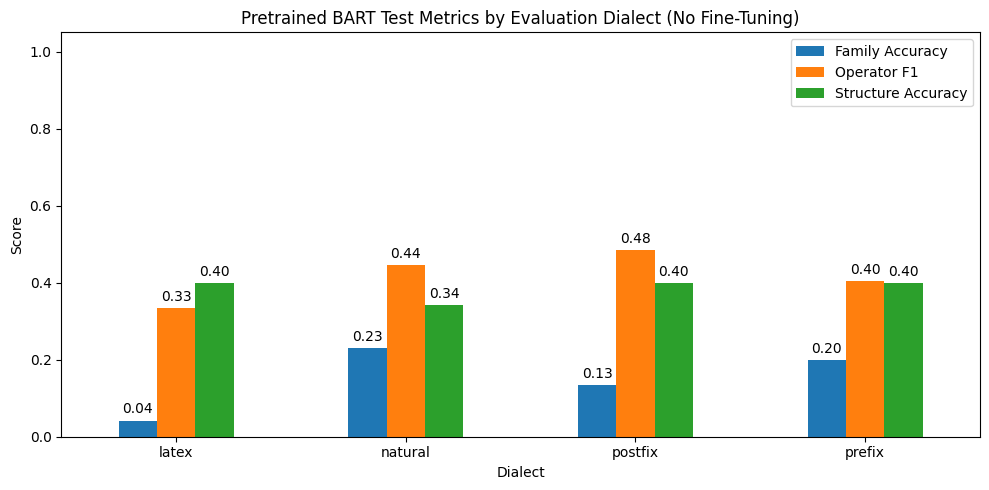

In [ ]:

plot_df = baseline_test_df[['family_accuracy', 'operator_micro_f1', 'structure_accuracy']].copy()
plot_df.columns = ['Family Accuracy', 'Operator F1', 'Structure Accuracy']

ax = plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0, 1.05), rot=0)
ax.set_title('Frozen-Backbone BART Test Metrics by Evaluation Dialect')
ax.set_ylabel('Score')
ax.set_xlabel('Dialect')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.tight_layout()
plt.show()


In [ ]:

config_summary = pd.DataFrame([
    {'Parameter': 'Model', 'Value': multitask_summary['config']['model_name']},
    {'Parameter': 'Freeze Backbone', 'Value': multitask_summary['config']['freeze_backbone']},
    {'Parameter': 'Skip Train', 'Value': multitask_summary['config']['skip_train']},
    {'Parameter': 'Train Mode', 'Value': multitask_summary['config']['train_mode']},
    {'Parameter': 'Train Dialect', 'Value': multitask_summary['config']['train_dialect']},
    {'Parameter': 'Eval Dialects', 'Value': ', '.join(multitask_summary['config']['eval_dialects'])},
    {'Parameter': 'Held-Out Datasets', 'Value': ', '.join(multitask_summary['config'].get('held_out_datasets', [])) or 'none'},
    {'Parameter': 'Split Mode', 'Value': multitask_summary['config']['split_mode']},
    {'Parameter': 'Dialect Tags', 'Value': 'disabled' if multitask_summary['config']['no_dialect_token'] else 'enabled'},
    {'Parameter': 'Device', 'Value': FROZEN_DEVICE},
    {'Parameter': 'Batch Size', 'Value': multitask_summary['config']['batch_size']},
    {'Parameter': 'Epochs', 'Value': multitask_summary['config']['num_epochs']},
    {'Parameter': 'Learning Rate', 'Value': multitask_summary['config']['learning_rate']},
    {'Parameter': 'Max Input Length', 'Value': multitask_summary['config']['max_input_length']},
    {'Parameter': 'Operator Loss Weight', 'Value': multitask_summary['config']['operator_loss_weight']},
    {'Parameter': 'Structure Loss Weight', 'Value': multitask_summary['config']['structure_loss_weight']},
])

print('Run configuration:')
display(config_summary)


Run configuration:


,Parameter,Value
0,Model,facebook/bart-base
1,Skip Train,True
2,Train Mode,mixed
3,Train Dialect,natural
4,Eval Dialects,"natural, latex, prefix, postfix"
5,Held-Out Datasets,"varied_data_generation/held_out_beam.jsonl, va..."
6,Split Mode,instance
7,Dialect Tags,disabled
8,Device,cpu
9,Batch Size,16



## Phase 4: Shared vs Single-Dialect Frozen-Backbone Comparison

This section mirrors the fine-tuned notebook, but here every run keeps the pretrained BART backbone frozen and trains only the multitask heads.

Interpretation note:
- the shared frozen-backbone run trains one shared set of heads on all four representations
- the four single-dialect runs train separate heads while keeping the same frozen language backbone
- because training still happens here, differences between the shared and single-dialect runs are meaningful


In [ ]:

SINGLE_DIALECT_FROZEN_RUNS = []

for dialect in PDE_DIALECTS:
    output_dir = FROZEN_ROOT_DIR / f'single_{dialect}_frozen_backbone'
    metrics_path = output_dir / 'multitask_metrics.json'
    cmd = [
        sys.executable,
        'scripts/run_bart_multitask_pde.py',
        '--train-mode', 'single',
        '--train-dialect', dialect,
        '--split-mode', 'instance',
        '--output-root', str(FROZEN_OUTPUT_ROOT),
        '--freeze-backbone',
        '--no-dialect-token',
        '--device', FROZEN_DEVICE,
    ]
    if HELD_OUT_DATASETS:
        cmd.extend(['--held-out-datasets', *[str(path) for path in HELD_OUT_DATASETS]])

    SINGLE_DIALECT_FROZEN_RUNS.append({
        'dialect': dialect,
        'label': f'Single frozen ({dialect})',
        'output_dir': output_dir,
        'metrics_path': metrics_path,
        'cmd': cmd,
    })
    print(f"[{dialect}] {' '.join(cmd)}")

for run in SINGLE_DIALECT_FROZEN_RUNS:
    print(f"\nRunning {run['label']} -> {run['output_dir']}")
    subprocess.run(run['cmd'], check=True)


[natural] /usr/local/bin/python3 scripts/run_bart_multitask_pde.py --train-mode single --train-dialect natural --split-mode instance --output-root outputs/bart_multitask_pde_no_fine_tune --skip-train --no-dialect-token --device cpu --held-out-datasets varied_data_generation/held_out_beam.jsonl varied_data_generation/held_out_dataset.jsonl varied_data_generation/held_out_kleingordon.jsonl varied_data_generation/held_out_reactiondiffusion.jsonl
[latex] /usr/local/bin/python3 scripts/run_bart_multitask_pde.py --train-mode single --train-dialect latex --split-mode instance --output-root outputs/bart_multitask_pde_no_fine_tune --skip-train --no-dialect-token --device cpu --held-out-datasets varied_data_generation/held_out_beam.jsonl varied_data_generation/held_out_dataset.jsonl varied_data_generation/held_out_kleingordon.jsonl varied_data_generation/held_out_reactiondiffusion.jsonl
[prefix] /usr/local/bin/python3 scripts/run_bart_multitask_pde.py --train-mode single --train-dialect prefix -

Some weights of BartPDEMultitaskClassifier were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['family_head.bias', 'family_head.weight', 'first_spatial_head.bias', 'first_spatial_head.weight', 'nonlinear_head.bias', 'nonlinear_head.weight', 'operator_head.bias', 'operator_head.weight', 'second_spatial_head.bias', 'second_spatial_head.weight', 'spatial_var_head.bias', 'spatial_var_head.weight', 'time_order_head.bias', 'time_order_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Skipping fine-tuning. Evaluating the pretrained BART backbone with randomly initialized multitask heads.
Running evaluation for dialect=natural
Eval on NATURAL | family_acc=23.00% | operator_f1=44.48% | structure_acc=34.16%
Running evaluation for dialect=latex
Eval on LATEX   | family_acc=4.20% | operator_f1=33.49% | structure_acc=40.00%
Running evaluation for dialect=prefix
Eval on PREFIX  | family_acc=20.00% | operator_f1=40.48% | structure_acc=40.00%
Running evaluation for dialect=postfix
Eval on POSTFIX | family_acc=13.40% | operator_f1=48.48% | structure_acc=40.00%
Held-out dataset held_out_beam contains unseen families ['Beam']. Family accuracy will be reported as n/a for those examples.
Held-out held_out_beam            | dialect=NATURAL | family_acc=n/a | operator_f1=62.74% | structure_acc=71.90% | top_family=Advection
Held-out held_out_beam            | dialect=LATEX   | family_acc=n/a | operator_f1=50.05% | structure_acc=60.00% | top_family=Wave
Held-out held_out_beam        

Some weights of BartPDEMultitaskClassifier were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['family_head.bias', 'family_head.weight', 'first_spatial_head.bias', 'first_spatial_head.weight', 'nonlinear_head.bias', 'nonlinear_head.weight', 'operator_head.bias', 'operator_head.weight', 'second_spatial_head.bias', 'second_spatial_head.weight', 'spatial_var_head.bias', 'spatial_var_head.weight', 'time_order_head.bias', 'time_order_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Skipping fine-tuning. Evaluating the pretrained BART backbone with randomly initialized multitask heads.
Running evaluation for dialect=natural
Eval on NATURAL | family_acc=23.00% | operator_f1=44.48% | structure_acc=34.16%
Running evaluation for dialect=latex
Eval on LATEX   | family_acc=4.20% | operator_f1=33.49% | structure_acc=40.00%
Running evaluation for dialect=prefix
Eval on PREFIX  | family_acc=20.00% | operator_f1=40.48% | structure_acc=40.00%
Running evaluation for dialect=postfix
Eval on POSTFIX | family_acc=13.40% | operator_f1=48.48% | structure_acc=40.00%
Held-out dataset held_out_beam contains unseen families ['Beam']. Family accuracy will be reported as n/a for those examples.
Held-out held_out_beam            | dialect=NATURAL | family_acc=n/a | operator_f1=62.74% | structure_acc=71.90% | top_family=Advection
Held-out held_out_beam            | dialect=LATEX   | family_acc=n/a | operator_f1=50.05% | structure_acc=60.00% | top_family=Wave
Held-out held_out_beam        

Some weights of BartPDEMultitaskClassifier were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['family_head.bias', 'family_head.weight', 'first_spatial_head.bias', 'first_spatial_head.weight', 'nonlinear_head.bias', 'nonlinear_head.weight', 'operator_head.bias', 'operator_head.weight', 'second_spatial_head.bias', 'second_spatial_head.weight', 'spatial_var_head.bias', 'spatial_var_head.weight', 'time_order_head.bias', 'time_order_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Skipping fine-tuning. Evaluating the pretrained BART backbone with randomly initialized multitask heads.
Running evaluation for dialect=natural
Eval on NATURAL | family_acc=23.00% | operator_f1=44.48% | structure_acc=34.16%
Running evaluation for dialect=latex
Eval on LATEX   | family_acc=4.20% | operator_f1=33.49% | structure_acc=40.00%
Running evaluation for dialect=prefix
Eval on PREFIX  | family_acc=20.00% | operator_f1=40.48% | structure_acc=40.00%
Running evaluation for dialect=postfix
Eval on POSTFIX | family_acc=13.40% | operator_f1=48.48% | structure_acc=40.00%
Held-out dataset held_out_beam contains unseen families ['Beam']. Family accuracy will be reported as n/a for those examples.
Held-out held_out_beam            | dialect=NATURAL | family_acc=n/a | operator_f1=62.74% | structure_acc=71.90% | top_family=Advection
Held-out held_out_beam            | dialect=LATEX   | family_acc=n/a | operator_f1=50.05% | structure_acc=60.00% | top_family=Wave
Held-out held_out_beam        

Some weights of BartPDEMultitaskClassifier were not initialized from the model checkpoint at facebook/bart-base and are newly initialized: ['family_head.bias', 'family_head.weight', 'first_spatial_head.bias', 'first_spatial_head.weight', 'nonlinear_head.bias', 'nonlinear_head.weight', 'operator_head.bias', 'operator_head.weight', 'second_spatial_head.bias', 'second_spatial_head.weight', 'spatial_var_head.bias', 'spatial_var_head.weight', 'time_order_head.bias', 'time_order_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Skipping fine-tuning. Evaluating the pretrained BART backbone with randomly initialized multitask heads.
Running evaluation for dialect=natural
Eval on NATURAL | family_acc=23.00% | operator_f1=44.48% | structure_acc=34.16%
Running evaluation for dialect=latex
Eval on LATEX   | family_acc=4.20% | operator_f1=33.49% | structure_acc=40.00%
Running evaluation for dialect=prefix
Eval on PREFIX  | family_acc=20.00% | operator_f1=40.48% | structure_acc=40.00%
Running evaluation for dialect=postfix
Eval on POSTFIX | family_acc=13.40% | operator_f1=48.48% | structure_acc=40.00%
Held-out dataset held_out_beam contains unseen families ['Beam']. Family accuracy will be reported as n/a for those examples.
Held-out held_out_beam            | dialect=NATURAL | family_acc=n/a | operator_f1=62.74% | structure_acc=71.90% | top_family=Advection
Held-out held_out_beam            | dialect=LATEX   | family_acc=n/a | operator_f1=50.05% | structure_acc=60.00% | top_family=Wave
Held-out held_out_beam        

In [ ]:

FROZEN_MODEL_RUN_SPECS = [
    {
        'model_key': 'shared_mixed_frozen',
        'label': 'Shared frozen (all 4 dialects)',
        'training_representation': 'natural + latex + prefix + postfix',
        'metrics_path': FROZEN_METRICS_PATH,
    }
]

for dialect in PDE_DIALECTS:
    FROZEN_MODEL_RUN_SPECS.append(
        {
            'model_key': f'single_{dialect}_frozen',
            'label': f'Single frozen ({dialect})',
            'training_representation': dialect,
            'metrics_path': FROZEN_ROOT_DIR / f'single_{dialect}_frozen_backbone' / 'multitask_metrics.json',
        }
    )

missing_metrics = [
    str(spec['metrics_path'])
    for spec in FROZEN_MODEL_RUN_SPECS
    if not spec['metrics_path'].exists()
]
if missing_metrics:
    raise FileNotFoundError(
        'Missing frozen-backbone multitask metric files. Run the shared baseline cell and the single-dialect frozen-backbone cell first:\n'
        + '\n'.join(missing_metrics)
    )

model_order = [spec['label'] for spec in FROZEN_MODEL_RUN_SPECS]
overall_rows = []
per_dialect_rows = []
held_out_compare_rows = []

for spec in FROZEN_MODEL_RUN_SPECS:
    with open(spec['metrics_path']) as handle:
        summary = json.load(handle)

    test_df = pd.DataFrame(summary['test_metrics']).T.sort_index()
    overall_row = {
        'Model': spec['label'],
        'Training Representation': spec['training_representation'],
        'Mean Family Acc': test_df['family_accuracy'].mean(),
        'Mean Operator F1': test_df['operator_micro_f1'].mean(),
        'Mean Structure Acc': test_df['structure_accuracy'].mean(),
        'Best Eval Dialect (Family)': test_df['family_accuracy'].idxmax(),
        'Best Eval Dialect (Operator)': test_df['operator_micro_f1'].idxmax(),
        'Best Eval Dialect (Structure)': test_df['structure_accuracy'].idxmax(),
    }

    for eval_dialect, row in test_df.iterrows():
        per_dialect_rows.append(
            {
                'Model': spec['label'],
                'Training Representation': spec['training_representation'],
                'Eval Dialect': eval_dialect,
                'Family Acc': row['family_accuracy'],
                'Operator F1': row['operator_micro_f1'],
                'Structure Acc': row['structure_accuracy'],
            }
        )

    held_out_frames = []
    for dataset_name, dataset_metrics in summary.get('held_out_metrics', {}).items():
        dataset_df = pd.DataFrame(dataset_metrics).T.sort_index()
        dataset_info = HELD_OUT_DATASET_INFO.get(dataset_name, {})
        top_predicted_family = ''
        if 'top_predicted_family' in dataset_df.columns:
            non_null_predictions = dataset_df['top_predicted_family'].dropna()
            if not non_null_predictions.empty:
                top_predicted_family = non_null_predictions.mode().iat[0]

        held_out_compare_rows.append(
            {
                'Model': spec['label'],
                'Training Representation': spec['training_representation'],
                'Held-Out Family': dataset_info.get('display_name', dataset_name),
                'Closest Seen Family': dataset_info.get('closest_seen_family', 'Unknown'),
                'Mean Operator F1': dataset_df['operator_micro_f1'].mean(),
                'Mean Structure Acc': dataset_df['structure_accuracy'].mean(),
                'Most Common Predicted Family': top_predicted_family,
            }
        )
        held_out_frames.append(dataset_df)

    if held_out_frames:
        combined_held_out_df = pd.concat(held_out_frames)
        overall_row['Mean Held-Out Operator F1'] = combined_held_out_df['operator_micro_f1'].mean()
        overall_row['Mean Held-Out Structure Acc'] = combined_held_out_df['structure_accuracy'].mean()

    overall_rows.append(overall_row)

overall_compare_df = pd.DataFrame(overall_rows).set_index('Model').loc[model_order]
print('Overall comparison across the shared frozen-backbone model and the four single-dialect frozen-backbone runs:')
display(overall_compare_df.style.format({
    'Mean Family Acc': '{:.2%}',
    'Mean Operator F1': '{:.2%}',
    'Mean Structure Acc': '{:.2%}',
    'Mean Held-Out Operator F1': '{:.2%}',
    'Mean Held-Out Structure Acc': '{:.2%}',
}, na_rep='n/a'))

per_dialect_compare_df = pd.DataFrame(per_dialect_rows)
per_dialect_compare_df['Model'] = pd.Categorical(
    per_dialect_compare_df['Model'], categories=model_order, ordered=True
)
per_dialect_compare_df['Eval Dialect'] = pd.Categorical(
    per_dialect_compare_df['Eval Dialect'], categories=PDE_DIALECTS, ordered=True
)
per_dialect_compare_df = per_dialect_compare_df.sort_values(['Eval Dialect', 'Model']).reset_index(drop=True)
print('Per-evaluation-dialect comparison (frozen backbone):')
display(per_dialect_compare_df.style.format({
    'Family Acc': '{:.2%}',
    'Operator F1': '{:.2%}',
    'Structure Acc': '{:.2%}',
}))

if held_out_compare_rows:
    held_out_compare_df = pd.DataFrame(held_out_compare_rows)
    held_out_compare_df['Model'] = pd.Categorical(
        held_out_compare_df['Model'], categories=model_order, ordered=True
    )
    held_out_compare_df = held_out_compare_df.sort_values(['Held-Out Family', 'Model']).reset_index(drop=True)
    print('Held-out family comparison (frozen backbone):')
    display(held_out_compare_df.style.format({
        'Mean Operator F1': '{:.2%}',
        'Mean Structure Acc': '{:.2%}',
    }))


Overall comparison across the shared no-fine-tune model and the four single-dialect no-fine-tune runs:


,Training Representation,Mean Family Acc,Mean Operator F1,Mean Structure Acc,Best Eval Dialect (Family),Best Eval Dialect (Operator),Best Eval Dialect (Structure),Mean Held-Out Operator F1,Mean Held-Out Structure Acc
Model,,,,,,,,,
Shared no-FT (all 4 dialects),natural + latex + prefix + postfix,15.15%,41.73%,38.54%,natural,postfix,latex,55.01%,43.94%
Single no-FT (natural),natural,15.15%,41.73%,38.54%,natural,postfix,latex,55.01%,43.94%
Single no-FT (latex),latex,15.15%,41.73%,38.54%,natural,postfix,latex,55.01%,43.94%
Single no-FT (prefix),prefix,15.15%,41.73%,38.54%,natural,postfix,latex,55.01%,43.94%
Single no-FT (postfix),postfix,15.15%,41.73%,38.54%,natural,postfix,latex,55.01%,43.94%


Per-evaluation-dialect comparison (no fine-tune):


,Model,Training Representation,Eval Dialect,Family Acc,Operator F1,Structure Acc
0,Shared no-FT (all 4 dialects),natural + latex + prefix + postfix,natural,23.00%,44.48%,34.16%
1,Single no-FT (natural),natural,natural,23.00%,44.48%,34.16%
2,Single no-FT (latex),latex,natural,23.00%,44.48%,34.16%
3,Single no-FT (prefix),prefix,natural,23.00%,44.48%,34.16%
4,Single no-FT (postfix),postfix,natural,23.00%,44.48%,34.16%
5,Shared no-FT (all 4 dialects),natural + latex + prefix + postfix,latex,4.20%,33.49%,40.00%
6,Single no-FT (natural),natural,latex,4.20%,33.49%,40.00%
7,Single no-FT (latex),latex,latex,4.20%,33.49%,40.00%
8,Single no-FT (prefix),prefix,latex,4.20%,33.49%,40.00%
9,Single no-FT (postfix),postfix,latex,4.20%,33.49%,40.00%


Held-out family comparison (no fine-tune):


,Model,Training Representation,Held-Out Family,Closest Seen Family,Mean Operator F1,Mean Structure Acc,Most Common Predicted Family
0,Shared no-FT (all 4 dialects),natural + latex + prefix + postfix,Beam,Wave,59.15%,67.97%,Wave
1,Single no-FT (natural),natural,Beam,Wave,59.15%,67.97%,Wave
2,Single no-FT (latex),latex,Beam,Wave,59.15%,67.97%,Wave
3,Single no-FT (prefix),prefix,Beam,Wave,59.15%,67.97%,Wave
4,Single no-FT (postfix),postfix,Beam,Wave,59.15%,67.97%,Wave
5,Shared no-FT (all 4 dialects),natural + latex + prefix + postfix,KleinGordon,Wave,58.87%,43.86%,Burgers
6,Single no-FT (natural),natural,KleinGordon,Wave,58.87%,43.86%,Burgers
7,Single no-FT (latex),latex,KleinGordon,Wave,58.87%,43.86%,Burgers
8,Single no-FT (prefix),prefix,KleinGordon,Wave,58.87%,43.86%,Burgers
9,Single no-FT (postfix),postfix,KleinGordon,Wave,58.87%,43.86%,Burgers


All aggregate no-fine-tune runs are numerically identical. That is expected because `--skip-train` disables learning, so changing `--train-mode` only changes bookkeeping.


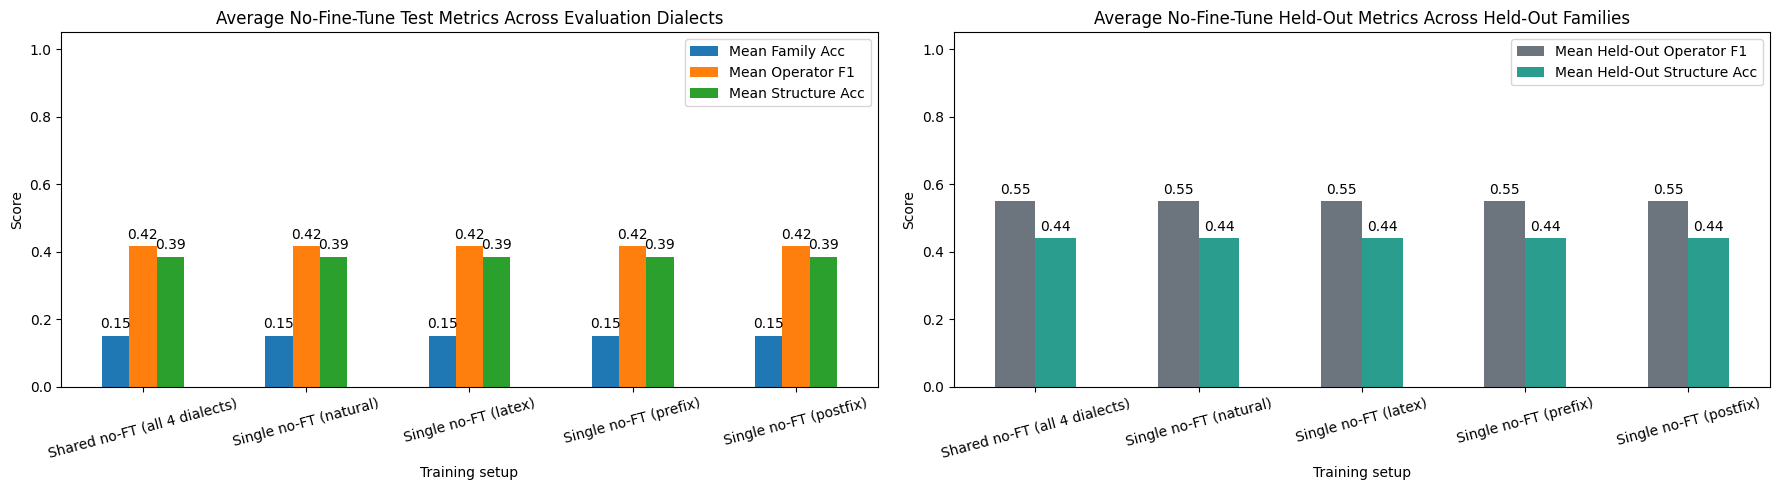

In [ ]:

plot_columns = ['Mean Family Acc', 'Mean Operator F1', 'Mean Structure Acc']
has_held_out_summary = {
    'Mean Held-Out Operator F1',
    'Mean Held-Out Structure Acc',
}.issubset(overall_compare_df.columns)

if has_held_out_summary:
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    test_ax, held_out_ax = axes
else:
    fig, test_ax = plt.subplots(1, 1, figsize=(10, 5))
    held_out_ax = None

overall_compare_df[plot_columns].plot(
    kind='bar',
    ax=test_ax,
    ylim=(0, 1.05),
    rot=15,
)
test_ax.set_title('Average Frozen-Backbone Test Metrics Across Evaluation Dialects')
test_ax.set_ylabel('Score')
test_ax.set_xlabel('Training setup')
for container in test_ax.containers:
    test_ax.bar_label(container, fmt='%.2f', padding=3)

if held_out_ax is not None:
    overall_compare_df[['Mean Held-Out Operator F1', 'Mean Held-Out Structure Acc']].plot(
        kind='bar',
        ax=held_out_ax,
        ylim=(0, 1.05),
        rot=15,
        color=['#6c757d', '#2a9d8f'],
    )
    held_out_ax.set_title('Average Frozen-Backbone Held-Out Metrics Across Held-Out Families')
    held_out_ax.set_ylabel('Score')
    held_out_ax.set_xlabel('Training setup')
    for container in held_out_ax.containers:
        held_out_ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()



## Conclusion

This notebook keeps the original full fine-tuning workflow only as reference, but the main experiment here is now a frozen-backbone BART baseline together with a shared-vs-single-dialect comparison layer.

That makes it easier to compare how much task performance can be recovered from representation learning in the pretrained backbone alone, once we allow the task heads to train but keep the language backbone fixed.
